# 📊 Analisi Commenti YouTube - Apple Vision Pro (Ottimizzato)

**Analisi completa dei commenti YouTube prima e dopo il lancio di Apple Vision Pro (2 febbraio 2024)**

## 🎯 Obiettivi:
1. **Estrazione dati** da API YouTube
2. **Sentiment Analysis** (TextBlob + VADER)
3. **Social Network Analysis** (NetworkX)
4. **Machine Learning** per classificazione temporale
5. **Clustering** per argomenti e uso
6. **Analisi comparativa** PRE/POST Vision Pro

## 1. 📚 Setup e Configurazione

In [13]:
# Importazione librerie
import pandas as pd
import numpy as np
import json
import os
import re
import time
import warnings
from datetime import datetime, timezone
from collections import Counter

# YouTube API
from googleapiclient.discovery import build

# Sentiment Analysis
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Network Analysis
import networkx as nx

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Configurazioni
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

print("✅ Librerie importate con successo!")

✅ Librerie importate con successo!


In [14]:
# Configurazione API YouTube
# NOTA: Sostituire con la propria API key
API_KEY = "YOUR_YOUTUBE_API_KEY_HERE"  # Configurare prima dell'uso

# Data di riferimento Apple Vision Pro
APPLE_VISION_PRO_LAUNCH = datetime(2024, 2, 2, tzinfo=timezone.utc)

print(f"📅 Data di riferimento Vision Pro: {APPLE_VISION_PRO_LAUNCH.strftime('%d/%m/%Y')}")
print(f"🔑 API Key configurata: {API_KEY != 'YOUR_YOUTUBE_API_KEY_HERE'}")

📅 Data di riferimento Vision Pro: 02/02/2024
🔑 API Key configurata: False


## 2. 🔄 Caricamento e Preprocessing Dati

In [15]:
# Carica dataset (assumendo che sia già stato estratto)
def load_youtube_data():
    """Carica i dati YouTube preprocessati"""
    try:
        # Prova a caricare il file esistente
        df = pd.read_csv('youtube_comments_analysis.csv')
        print(f"✅ Dataset caricato: {len(df):,} commenti")
        return df
    except FileNotFoundError:
        print("❌ File non trovato. Assicurarsi di aver eseguito l'estrazione dati.")
        return None

# Funzioni di preprocessing
def clean_text(text):
    """Pulisce il testo per l'analisi"""
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'http\S+|www.\S+', '', text)  # URL
    text = re.sub(r'[@#](\w+)', r'\1', text)      # Menzioni/hashtag
    text = re.sub(r'[^\w\s]', ' ', text)         # Punteggiatura
    text = re.sub(r'\s+', ' ', text).strip()     # Spazi multipli
    
    return text

def categorize_by_vision_pro(timestamp_str):
    """Categorizza commento come prima/dopo Vision Pro"""
    try:
        comment_date = datetime.fromisoformat(timestamp_str.replace('Z', '+00:00'))
        return 'prima' if comment_date < APPLE_VISION_PRO_LAUNCH else 'dopo'
    except:
        return 'dopo'  # Default per timestamp invalidi

# Carica e preprocessa dati
df_comments = load_youtube_data()

if df_comments is not None:
    # Preprocessing
    df_comments['testo_pulito'] = df_comments['testo_commento'].apply(clean_text)
    
    # Rimuovi commenti troppo corti
    df_comments = df_comments[df_comments['testo_pulito'].str.len() >= 10]
    
    print(f"📊 Dopo preprocessing: {len(df_comments):,} commenti validi")
    print(f"📊 PRE Vision Pro: {len(df_comments[df_comments['prima_dopo_vision_pro'] == 'prima']):,}")
    print(f"📊 POST Vision Pro: {len(df_comments[df_comments['prima_dopo_vision_pro'] == 'dopo']):,}")
else:
    print("⚠️ Impossibile procedere senza dati")

✅ Dataset caricato: 124,771 commenti
📊 Dopo preprocessing: 118,602 commenti validi
📊 PRE Vision Pro: 82,751
📊 POST Vision Pro: 35,851
📊 Dopo preprocessing: 118,602 commenti validi
📊 PRE Vision Pro: 82,751
📊 POST Vision Pro: 35,851


## 3. 😊 Sentiment Analysis

In [16]:
# Setup sentiment analyzers
analyzer_vader = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """Analizza sentiment con TextBlob e VADER"""
    if pd.isna(text) or text == "":
        return 0, 0, 'neutrale'
    
    # TextBlob
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    
    # VADER
    vader_scores = analyzer_vader.polarity_scores(text)
    compound = vader_scores['compound']
    
    # Categorizzazione
    if polarity > 0.1:
        categoria = 'positivo'
    elif polarity < -0.1:
        categoria = 'negativo'
    else:
        categoria = 'neutrale'
    
    return polarity, compound, categoria

# Applica sentiment analysis
if df_comments is not None:
    print("🔄 Calcolo sentiment...")
    
    sentiment_results = df_comments['testo_pulito'].apply(analyze_sentiment)
    
    df_comments['polarity'] = [x[0] for x in sentiment_results]
    df_comments['compound'] = [x[1] for x in sentiment_results]
    df_comments['sentiment'] = [x[2] for x in sentiment_results]
    
    # Statistiche sentiment
    pre_data = df_comments[df_comments['prima_dopo_vision_pro'] == 'prima']
    post_data = df_comments[df_comments['prima_dopo_vision_pro'] == 'dopo']
    
    print(f"\n📊 STATISTICHE SENTIMENT:")
    print(f"                    PRE      POST    DIFFERENZA")
    print(f"Polarità Media:    {pre_data['polarity'].mean():6.3f}   {post_data['polarity'].mean():6.3f}   {post_data['polarity'].mean()-pre_data['polarity'].mean():+6.3f}")
    print(f"VADER Compound:    {pre_data['compound'].mean():6.3f}   {post_data['compound'].mean():6.3f}   {post_data['compound'].mean()-pre_data['compound'].mean():+6.3f}")
    
    # Interpretazione
    change = post_data['polarity'].mean() - pre_data['polarity'].mean()
    if change > 0.05:
        print("\n✅ Sentiment migliorato dopo Vision Pro!")
    elif change < -0.05:
        print("\n❌ Sentiment peggiorato dopo Vision Pro!")
    else:
        print("\n➡️ Sentiment stabile!")

🔄 Calcolo sentiment...

📊 STATISTICHE SENTIMENT:
                    PRE      POST    DIFFERENZA
Polarità Media:     0.095    0.094   -0.001
VADER Compound:     0.168    0.177   +0.009

➡️ Sentiment stabile!

📊 STATISTICHE SENTIMENT:
                    PRE      POST    DIFFERENZA
Polarità Media:     0.095    0.094   -0.001
VADER Compound:     0.168    0.177   +0.009

➡️ Sentiment stabile!


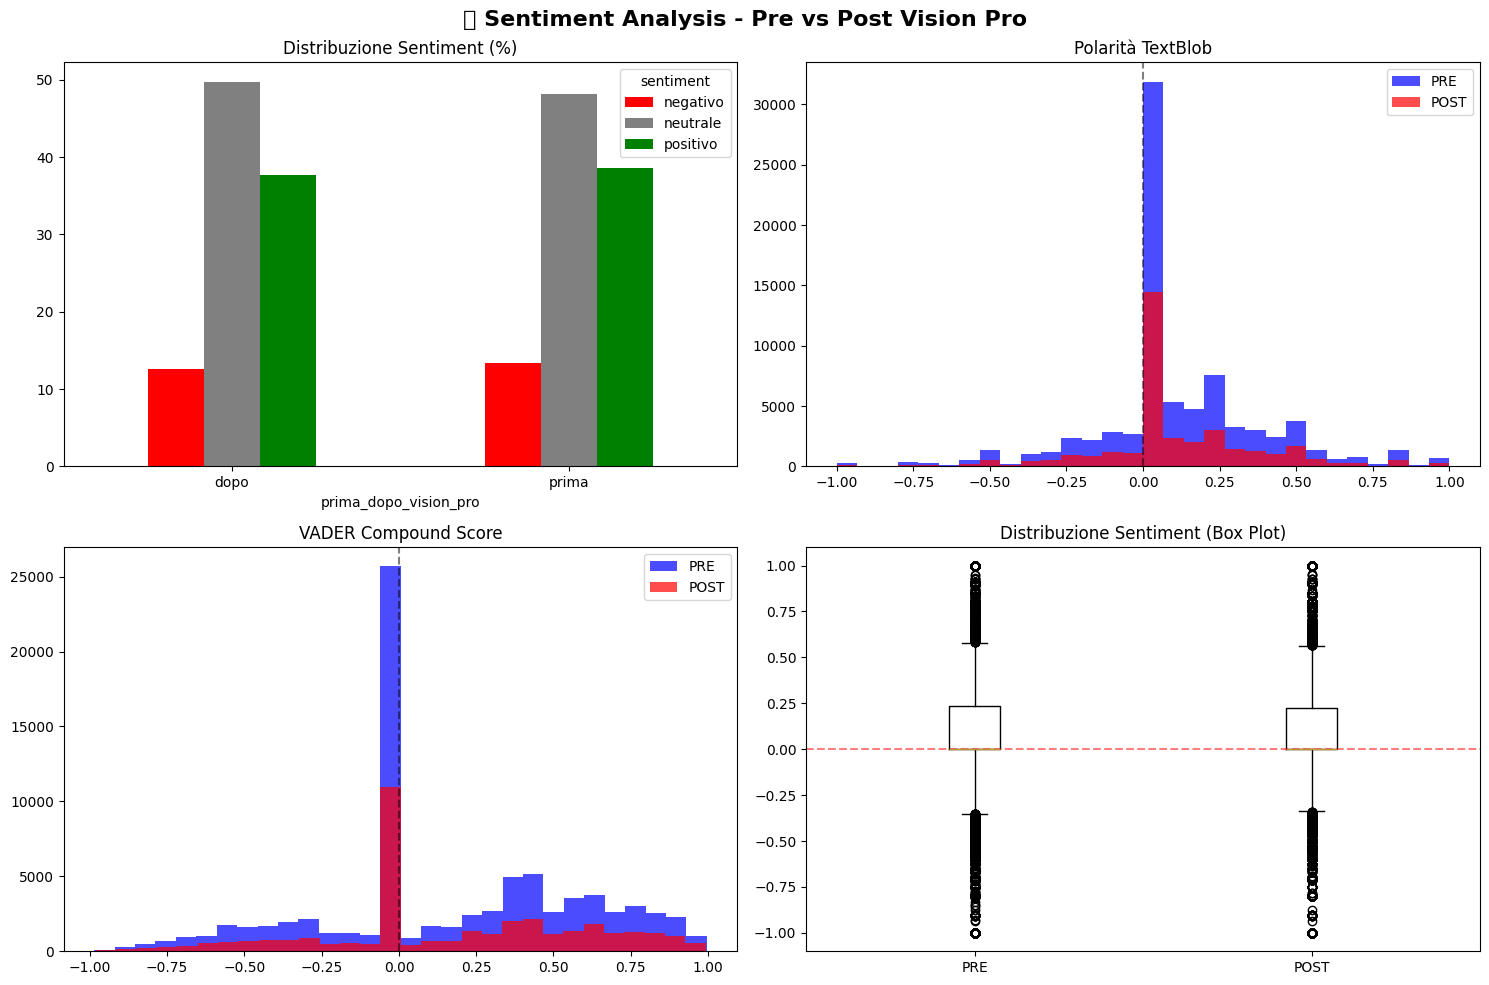

✅ Visualizzazioni sentiment completate


In [17]:
# Visualizzazioni sentiment
if df_comments is not None:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('📊 Sentiment Analysis - Pre vs Post Vision Pro', fontsize=16, fontweight='bold')
    
    # 1. Distribuzione sentiment
    sentiment_crosstab = pd.crosstab(df_comments['prima_dopo_vision_pro'], 
                                   df_comments['sentiment'], normalize='index') * 100
    sentiment_crosstab.plot(kind='bar', ax=axes[0,0], color=['red', 'gray', 'green'])
    axes[0,0].set_title('Distribuzione Sentiment (%)')
    axes[0,0].tick_params(axis='x', rotation=0)
    
    # 2. Polarità TextBlob
    axes[0,1].hist(pre_data['polarity'], bins=30, alpha=0.7, label='PRE', color='blue')
    axes[0,1].hist(post_data['polarity'], bins=30, alpha=0.7, label='POST', color='red')
    axes[0,1].set_title('Polarità TextBlob')
    axes[0,1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
    axes[0,1].legend()
    
    # 3. VADER Compound
    axes[1,0].hist(pre_data['compound'], bins=30, alpha=0.7, label='PRE', color='blue')
    axes[1,0].hist(post_data['compound'], bins=30, alpha=0.7, label='POST', color='red')
    axes[1,0].set_title('VADER Compound Score')
    axes[1,0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
    axes[1,0].legend()
    
    # 4. Box plot comparativo
    sentiment_data = [pre_data['polarity'], post_data['polarity']]
    axes[1,1].boxplot(sentiment_data, labels=['PRE', 'POST'])
    axes[1,1].set_title('Distribuzione Sentiment (Box Plot)')
    axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizzazioni sentiment completate")

## 4. 🌐 Social Network Analysis

In [18]:
# Costruzione network basato su risposte dirette
def create_user_network(data, period_name):
    """Crea network degli utenti basato su interazioni dirette"""
    G = nx.Graph()
    
    # Filtra solo commenti con parent (risposte)
    replies = data[data['id_commento_padre'].notna()]
    
    # Mappa commento -> autore
    comment_to_author = dict(zip(data['id_commento'], data['autore']))
    
    # Crea archi tra chi risponde e chi riceve risposta
    for _, reply in replies.iterrows():
        parent_id = reply['id_commento_padre']
        if parent_id in comment_to_author:
            parent_author = comment_to_author[parent_id]
            reply_author = reply['autore']
            
            if parent_author != reply_author:  # Evita self-loops
                if G.has_edge(parent_author, reply_author):
                    G[parent_author][reply_author]['weight'] += 1
                else:
                    G.add_edge(parent_author, reply_author, weight=1)
    
    print(f"🌐 Network {period_name}: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")
    return G

# Calcola metriche network con centralità
def analyze_network_metrics(G, name):
    """Calcola metriche fondamentali del network incluse le centralità"""
    if G.number_of_nodes() == 0:
        return {}
    
    print(f"📊 Calcolando metriche per network {name}...")
    
    metrics = {
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G),
        'components': nx.number_connected_components(G)
    }
    
    # Grado medio
    degrees = [G.degree(n) for n in G.nodes()]
    metrics['avg_degree'] = np.mean(degrees) if degrees else 0
    
    # Clustering coefficient (campionato se grande)
    if G.number_of_nodes() > 1000:
        sample_nodes = np.random.choice(list(G.nodes()), 500, replace=False)
        clustering_values = [nx.clustering(G, node) for node in sample_nodes]
        metrics['avg_clustering'] = np.mean(clustering_values)
    else:
        metrics['avg_clustering'] = nx.average_clustering(G)
    
    # === METRICHE DI CENTRALITÀ ===
    
    # 1. DEGREE CENTRALITY (sempre calcolabile, veloce)
    degree_centrality = nx.degree_centrality(G)
    metrics['degree_centrality'] = degree_centrality
    metrics['avg_degree_centrality'] = np.mean(list(degree_centrality.values()))
    
    # Top 5 utenti per degree centrality
    top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    metrics['top_degree_centrality'] = top_degree
    
    # 2. BETWEENNESS CENTRALITY (ottimizzato per grafi grandi)
    print(f"   Calcolando betweenness centrality...")
    try:
        if G.number_of_nodes() > 1000:
            # Usa campionamento per grafi grandi
            k_sample = min(500, G.number_of_nodes())
            betweenness_centrality = nx.betweenness_centrality(G, k=k_sample)
            print(f"   → Betweenness calcolato su campione di {k_sample} nodi")
        else:
            betweenness_centrality = nx.betweenness_centrality(G)
            
        metrics['betweenness_centrality'] = betweenness_centrality
        metrics['avg_betweenness_centrality'] = np.mean(list(betweenness_centrality.values()))
        
        # Top 5 utenti per betweenness centrality
        top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
        metrics['top_betweenness_centrality'] = top_betweenness
        
    except Exception as e:
        print(f"   ⚠️ Errore betweenness centrality: {e}")
        metrics['betweenness_centrality'] = {}
        metrics['avg_betweenness_centrality'] = 0
        metrics['top_betweenness_centrality'] = []
    
    # 3. PAGERANK (ottimizzato)
    print(f"   Calcolando PageRank...")
    try:
        pagerank = nx.pagerank(G, max_iter=100, tol=1e-6)
        metrics['pagerank'] = pagerank
        metrics['avg_pagerank'] = np.mean(list(pagerank.values()))
        
        # Top 5 utenti per PageRank
        top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
        metrics['top_pagerank'] = top_pagerank
        
    except Exception as e:
        print(f"   ⚠️ Errore PageRank: {e}")
        metrics['pagerank'] = {}
        metrics['avg_pagerank'] = 0
        metrics['top_pagerank'] = []
    
    print(f"   ✅ Metriche {name} completate!")
    return metrics

# Costruisci network per PRE e POST
if df_comments is not None:
    print("🔄 Costruzione network...")
    
    G_pre = create_user_network(pre_data, "PRE")
    G_post = create_user_network(post_data, "POST")
    G_combined = create_user_network(df_comments, "COMBINATO")
    
    # Analizza metriche con centralità
    metrics_pre = analyze_network_metrics(G_pre, "PRE")
    metrics_post = analyze_network_metrics(G_post, "POST")
    
    print(f"\n📊 METRICHE NETWORK:")
    print(f"                         PRE         POST")
    if metrics_pre and metrics_post:
        print(f"Nodi:                   {metrics_pre['nodes']:8,}    {metrics_post['nodes']:8,}")
        print(f"Archi:                  {metrics_pre['edges']:8,}    {metrics_post['edges']:8,}")
        print(f"Densità:                {metrics_pre['density']:8.4f}    {metrics_post['density']:8.4f}")
        print(f"Grado medio:            {metrics_pre['avg_degree']:8.2f}    {metrics_post['avg_degree']:8.2f}")
        print(f"Clustering:             {metrics_pre['avg_clustering']:8.4f}    {metrics_post['avg_clustering']:8.4f}")
        print(f"\n🎯 METRICHE DI CENTRALITÀ:")
        print(f"Degree Centrality:      {metrics_pre['avg_degree_centrality']:8.4f}    {metrics_post['avg_degree_centrality']:8.4f}")
        print(f"Betweenness Centrality: {metrics_pre['avg_betweenness_centrality']:8.4f}    {metrics_post['avg_betweenness_centrality']:8.4f}")
        print(f"PageRank:               {metrics_pre['avg_pagerank']:8.4f}    {metrics_post['avg_pagerank']:8.4f}")
        
        # Top utenti per centralità
        print(f"\n👑 TOP 5 UTENTI PER CENTRALITÀ - PERIODO PRE:")
        print(f"\n🎯 Degree Centrality:")
        for i, (user, score) in enumerate(metrics_pre['top_degree_centrality'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")
            
        print(f"\n🌉 Betweenness Centrality:")
        for i, (user, score) in enumerate(metrics_pre['top_betweenness_centrality'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")
            
        print(f"\n🔗 PageRank:")
        for i, (user, score) in enumerate(metrics_pre['top_pagerank'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")
        
        print(f"\n👑 TOP 5 UTENTI PER CENTRALITÀ - PERIODO POST:")
        print(f"\n🎯 Degree Centrality:")
        for i, (user, score) in enumerate(metrics_post['top_degree_centrality'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")
            
        print(f"\n🌉 Betweenness Centrality:")
        for i, (user, score) in enumerate(metrics_post['top_betweenness_centrality'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")
            
        print(f"\n🔗 PageRank:")
        for i, (user, score) in enumerate(metrics_post['top_pagerank'], 1):
            user_short = user[:25] + "..." if len(user) > 25 else user
            print(f"   {i}. {user_short:<28} {score:.4f}")

🔄 Costruzione network...
🌐 Network PRE: 8271 nodi, 6568 archi
🌐 Network POST: 3650 nodi, 2816 archi
🌐 Network PRE: 8271 nodi, 6568 archi
🌐 Network POST: 3650 nodi, 2816 archi
🌐 Network COMBINATO: 11897 nodi, 9534 archi
📊 Calcolando metriche per network PRE...
   Calcolando betweenness centrality...
🌐 Network COMBINATO: 11897 nodi, 9534 archi
📊 Calcolando metriche per network PRE...
   Calcolando betweenness centrality...


   → Betweenness calcolato su campione di 500 nodi
   Calcolando PageRank...
   ✅ Metriche PRE completate!
📊 Calcolando metriche per network POST...
   Calcolando betweenness centrality...
   → Betweenness calcolato su campione di 500 nodi
   Calcolando PageRank...
   ✅ Metriche POST completate!

📊 METRICHE NETWORK:
                         PRE         POST
Nodi:                      8,271       3,650
Archi:                     6,568       2,816
Densità:                  0.0002      0.0004
Grado medio:                1.59        1.54
Clustering:               0.0000      0.0007

🎯 METRICHE DI CENTRALITÀ:
Degree Centrality:        0.0002      0.0004
Betweenness Centrality:   0.0001      0.0000
PageRank:                 0.0001      0.0003

👑 TOP 5 UTENTI PER CENTRALITÀ - PERIODO PRE:

🎯 Degree Centrality:
   1. @officialANON001             0.0073
   2. @zavierwiley                 0.0062
   3. @sqlevolicious               0.0046
   4. @piouslake2816               0.0046
   5. @zwenkwiel8

## 5. 🤖 Machine Learning

In [19]:
# Preparazione dati per ML
if df_comments is not None:
    # Crea dataset bilanciato
    pre_ml = df_comments[df_comments['prima_dopo_vision_pro'] == 'prima'].sample(n=min(3000, len(pre_data)), random_state=42)
    post_ml = df_comments[df_comments['prima_dopo_vision_pro'] == 'dopo'].sample(n=min(3000, len(post_data)), random_state=42)
    
    df_ml = pd.concat([pre_ml, post_ml], ignore_index=True)
    
    # Target: 0=PRE, 1=POST
    df_ml['target'] = (df_ml['prima_dopo_vision_pro'] == 'dopo').astype(int)
    
    print(f"📊 Dataset ML: {len(df_ml)} commenti bilanciati")
    
    # Feature extraction con TF-IDF
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        stop_words='english'
    )
    
    X = vectorizer.fit_transform(df_ml['testo_pulito'])
    y = df_ml['target']
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    print(f"📊 Training set: {X_train.shape[0]} samples")
    print(f"📊 Test set: {X_test.shape[0]} samples")

📊 Dataset ML: 6000 commenti bilanciati
📊 Training set: 4800 samples
📊 Test set: 1200 samples
📊 Training set: 4800 samples
📊 Test set: 1200 samples


In [20]:
# Training modelli ML
if 'X_train' in locals():
    print("🤖 Training modelli...")
    
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"🔄 Training {name}...")
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Evaluate
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'predictions': y_pred
        }
        
        print(f"   ✅ {name}: {accuracy:.3f} accuracy")
    
    # Migliore modello
    best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
    best_model = results[best_model_name]['model']
    
    print(f"\n🏆 Migliore modello: {best_model_name} ({results[best_model_name]['accuracy']:.3f})")
    
    # Classification report del migliore
    print(f"\n📋 Classification Report - {best_model_name}:")
    print(classification_report(y_test, results[best_model_name]['predictions'], 
                              target_names=['PRE', 'POST']))

🤖 Training modelli...
🔄 Training Logistic Regression...
   ✅ Logistic Regression: 0.542 accuracy
🔄 Training Random Forest...
   ✅ Random Forest: 0.547 accuracy

🏆 Migliore modello: Random Forest (0.547)

📋 Classification Report - Random Forest:
              precision    recall  f1-score   support

         PRE       0.55      0.50      0.52       600
        POST       0.54      0.60      0.57       600

    accuracy                           0.55      1200
   macro avg       0.55      0.55      0.55      1200
weighted avg       0.55      0.55      0.55      1200

   ✅ Random Forest: 0.547 accuracy

🏆 Migliore modello: Random Forest (0.547)

📋 Classification Report - Random Forest:
              precision    recall  f1-score   support

         PRE       0.55      0.50      0.52       600
        POST       0.54      0.60      0.57       600

    accuracy                           0.55      1200
   macro avg       0.55      0.55      0.55      1200
weighted avg       0.55      0.55   

## 6. 🎯 Clustering e Analisi Tematiche

In [21]:
# Analisi tematiche con keyword clustering
if df_comments is not None:
    # Definisci cluster tematici
    topic_keywords = {
        'price': ['price', 'cost', 'expensive', 'cheap', 'money', 'dollar', 'afford', 'worth'],
        'technology': ['tech', 'innovation', 'processor', 'display', 'battery', 'advanced'],
        'usability': ['easy', 'difficult', 'comfortable', 'heavy', 'ergonomic', 'user-friendly'],
        'gaming': ['game', 'gaming', 'play', 'vr games', 'immersive', 'virtual reality'],
        'comparison': ['better', 'worse', 'compare', 'versus', 'meta', 'quest', 'oculus']
    }
    
    def classify_topic(text):
        """Classifica il topic principale del commento"""
        text_lower = text.lower()
        scores = {}
        
        for topic, keywords in topic_keywords.items():
            score = sum(1 for keyword in keywords if keyword in text_lower)
            if score > 0:
                scores[topic] = score
        
        return max(scores, key=scores.get) if scores else 'other'
    
    # Applica classificazione
    df_comments['topic'] = df_comments['testo_pulito'].apply(classify_topic)
    
    # Analisi distribuzione topic
    print("📊 DISTRIBUZIONE ARGOMENTI:")
    topic_dist = df_comments['topic'].value_counts()
    
    for topic, count in topic_dist.items():
        pct = count / len(df_comments) * 100
        print(f"   {topic.capitalize():<12}: {count:>6,} ({pct:>5.1f}%)")
    
    # Analisi per periodo
    topic_period_crosstab = pd.crosstab(df_comments['topic'], 
                                       df_comments['prima_dopo_vision_pro'], 
                                       normalize='columns') * 100
    
    print(f"\n📈 ARGOMENTI PER PERIODO (%):")  
    print(topic_period_crosstab.round(1))

📊 DISTRIBUZIONE ARGOMENTI:
   Other       : 81,025 ( 68.3%)
   Price       : 13,034 ( 11.0%)
   Technology  : 10,360 (  8.7%)
   Gaming      :  6,868 (  5.8%)
   Comparison  :  6,307 (  5.3%)
   Usability   :  1,008 (  0.8%)

📈 ARGOMENTI PER PERIODO (%):
prima_dopo_vision_pro  dopo  prima
topic                             
comparison              5.8    5.1
gaming                  6.0    5.7
other                  69.0   68.0
price                  10.1   11.4
technology              8.3    8.9
usability               0.9    0.8


## 7. 📊 Word Cloud e Analisi Linguistica

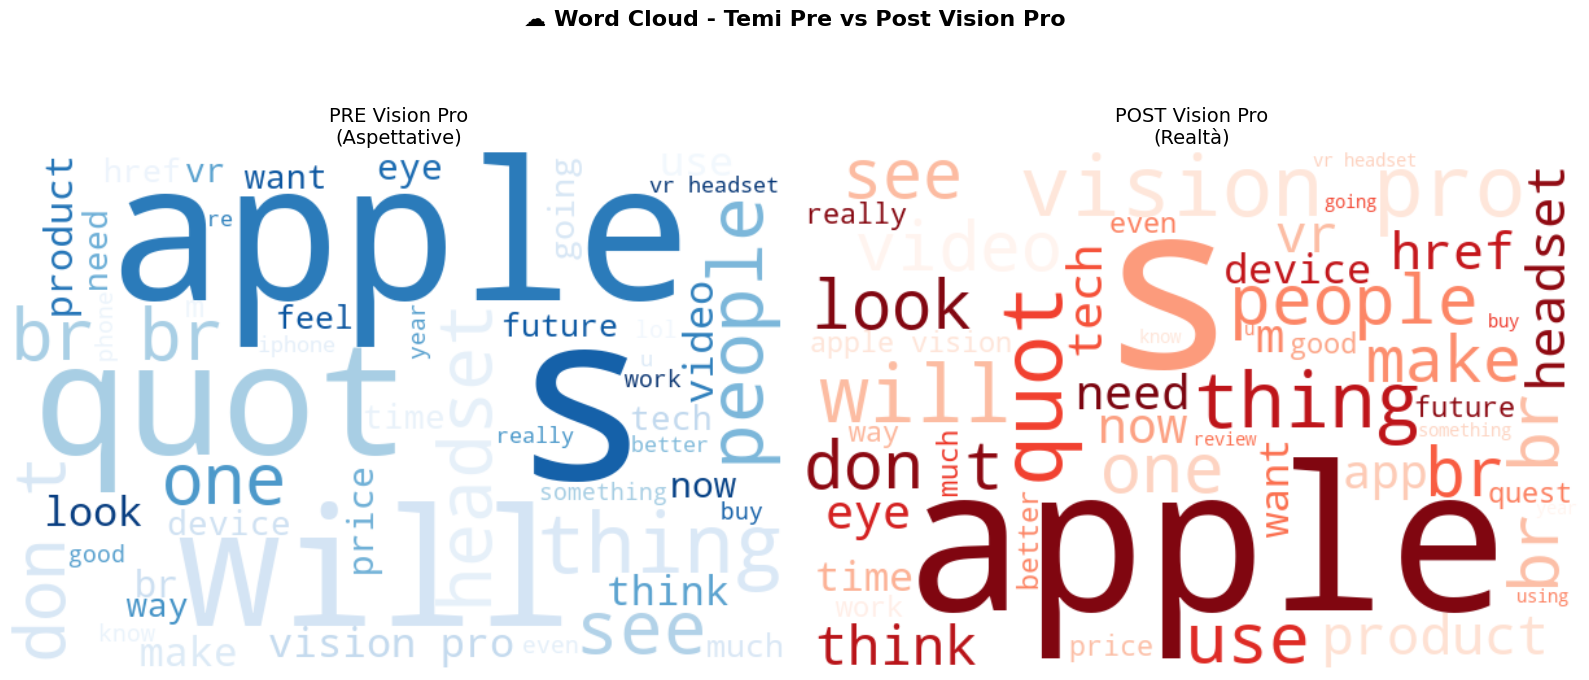

🔥 TOP 10 PAROLE PRE Vision Pro:
   apple: 15,408
   like: 12,646
   they: 9,817
   just: 9,370
   your: 8,473
   what: 7,562
   quot: 7,259
   people: 6,583
   would: 6,380
   headset: 5,486

🔥 TOP 10 PAROLE POST Vision Pro:
   apple: 7,013
   like: 5,567
   just: 4,192
   they: 4,096
   vision: 3,988
   your: 3,713
   quot: 3,540
   what: 3,367
   would: 2,815
   people: 2,548


In [22]:
# Word Cloud PRE vs POST
if df_comments is not None:
    # Prepara testi
    pre_text = ' '.join(pre_data['testo_pulito'])
    post_text = ' '.join(post_data['testo_pulito'])
    
    # Word clouds
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('☁️ Word Cloud - Temi Pre vs Post Vision Pro', fontsize=16, fontweight='bold')
    
    # PRE
    if pre_text.strip():
        wordcloud_pre = WordCloud(width=600, height=400, background_color='white',
                                 colormap='Blues', max_words=50).generate(pre_text)
        axes[0].imshow(wordcloud_pre, interpolation='bilinear')
        axes[0].set_title('PRE Vision Pro\n(Aspettative)', fontsize=14)
        axes[0].axis('off')
    
    # POST
    if post_text.strip():
        wordcloud_post = WordCloud(width=600, height=400, background_color='white',
                                  colormap='Reds', max_words=50).generate(post_text)
        axes[1].imshow(wordcloud_post, interpolation='bilinear')
        axes[1].set_title('POST Vision Pro\n(Realtà)', fontsize=14)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Top words analysis
    def get_top_words(text, n=10):
        words = text.split()
        stopwords = {'the', 'and', 'for', 'are', 'with', 'this', 'that', 'have', 'will'}
        words = [w for w in words if w not in stopwords and len(w) > 3]
        return Counter(words).most_common(n)
    
    pre_words = get_top_words(pre_text)
    post_words = get_top_words(post_text)
    
    print("🔥 TOP 10 PAROLE PRE Vision Pro:")
    for word, count in pre_words:
        print(f"   {word}: {count:,}")
    
    print("\n🔥 TOP 10 PAROLE POST Vision Pro:")
    for word, count in post_words:
        print(f"   {word}: {count:,}")

## 8. 📈 Visualizzazioni Comparative Finali

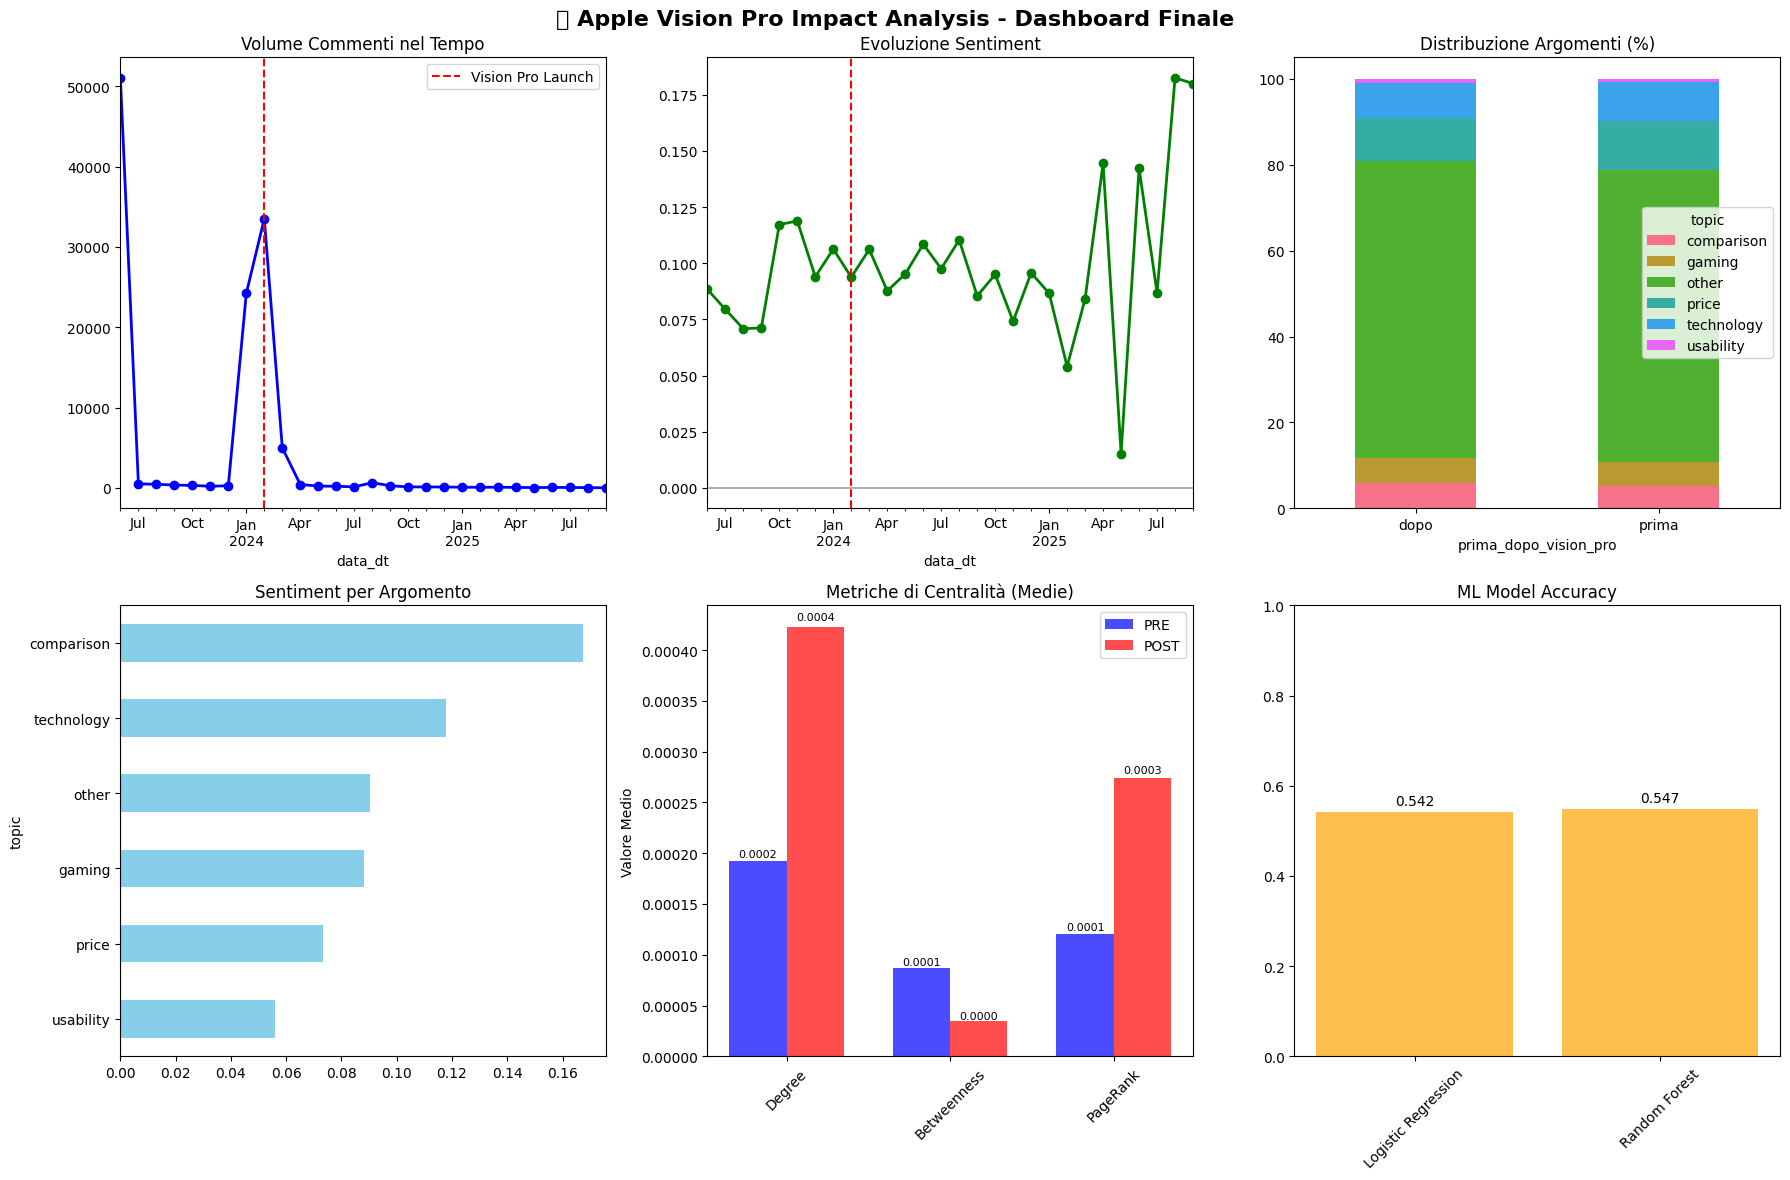

✅ Dashboard finale completato!


In [23]:
# Dashboard conclusivo
if df_comments is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('📊 Apple Vision Pro Impact Analysis - Dashboard Finale', 
                 fontsize=16, fontweight='bold')
    
    # 1. Volume commenti nel tempo
    df_comments['data_dt'] = pd.to_datetime(df_comments['data_commento'])
    monthly_volume = df_comments.groupby([df_comments['data_dt'].dt.to_period('M')]).size()
    monthly_volume.plot(ax=axes[0,0], marker='o', linewidth=2, color='blue')
    axes[0,0].axvline(x=pd.Period('2024-02'), color='red', linestyle='--', 
                     label='Vision Pro Launch')
    axes[0,0].set_title('Volume Commenti nel Tempo')
    axes[0,0].legend()
    
    # 2. Sentiment evolution
    monthly_sentiment = df_comments.groupby([df_comments['data_dt'].dt.to_period('M')])['polarity'].mean()
    monthly_sentiment.plot(ax=axes[0,1], marker='o', linewidth=2, color='green')
    axes[0,1].axvline(x=pd.Period('2024-02'), color='red', linestyle='--')
    axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0,1].set_title('Evoluzione Sentiment')
    
    # 3. Topic distribution comparison
    topic_comparison = pd.crosstab(df_comments['prima_dopo_vision_pro'], 
                                  df_comments['topic'], normalize='index') * 100
    topic_comparison.plot(kind='bar', ax=axes[0,2], stacked=True)
    axes[0,2].set_title('Distribuzione Argomenti (%)')
    axes[0,2].tick_params(axis='x', rotation=0)
    
    # 4. Sentiment by topic
    topic_sentiment = df_comments.groupby('topic')['polarity'].mean().sort_values()
    topic_sentiment.plot(kind='barh', ax=axes[1,0], color='skyblue')
    axes[1,0].axvline(x=0, color='red', linestyle='--')
    axes[1,0].set_title('Sentiment per Argomento')
    
    # 5. Metriche di Centralità (se disponibili)
    if 'metrics_pre' in locals() and 'metrics_post' in locals() and metrics_pre and metrics_post:
        # Confronto metriche di centralità
        centrality_metrics = ['avg_degree_centrality', 'avg_betweenness_centrality', 'avg_pagerank']
        centrality_names = ['Degree', 'Betweenness', 'PageRank']
        
        pre_centrality = [metrics_pre.get(m, 0) for m in centrality_metrics]
        post_centrality = [metrics_post.get(m, 0) for m in centrality_metrics]
        
        x = np.arange(len(centrality_names))
        width = 0.35
        
        axes[1,1].bar(x - width/2, pre_centrality, width, label='PRE', alpha=0.7, color='blue')
        axes[1,1].bar(x + width/2, post_centrality, width, label='POST', alpha=0.7, color='red')
        axes[1,1].set_title('Metriche di Centralità (Medie)')
        axes[1,1].set_xticks(x)
        axes[1,1].set_xticklabels(centrality_names, rotation=45)
        axes[1,1].legend()
        axes[1,1].set_ylabel('Valore Medio')
        
        # Aggiungi valori sopra le barre
        for i, (pre_val, post_val) in enumerate(zip(pre_centrality, post_centrality)):
            if pre_val > 0:
                axes[1,1].text(i - width/2, pre_val + pre_val*0.01, f'{pre_val:.4f}', 
                              ha='center', va='bottom', fontsize=8)
            if post_val > 0:
                axes[1,1].text(i + width/2, post_val + post_val*0.01, f'{post_val:.4f}', 
                              ha='center', va='bottom', fontsize=8)
    else:
        axes[1,1].text(0.5, 0.5, 'Metriche di\ncentralità\nnon disponibili', 
                      ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Centralità Network')
    
    # 6. ML Model performance (se disponibile)
    if 'results' in locals():
        model_names = list(results.keys())
        accuracies = [results[name]['accuracy'] for name in model_names]
        
        axes[1,2].bar(model_names, accuracies, color='orange', alpha=0.7)
        axes[1,2].set_title('ML Model Accuracy')
        axes[1,2].set_ylim(0, 1)
        axes[1,2].tick_params(axis='x', rotation=45)
        
        # Aggiungi valori sopra le barre
        for i, acc in enumerate(accuracies):
            axes[1,2].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')
    else:
        axes[1,2].text(0.5, 0.5, 'ML results\nnot available', 
                      ha='center', va='center', transform=axes[1,2].transAxes)
        axes[1,2].set_title('ML Model Performance')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Dashboard finale completato!")

## 9. 💾 Export Risultati e Summary

In [ ]:
    if 'metrics_pre' in locals() and 'metrics_post' in locals():
        print(f"\n🌐 NETWORK:")
        if metrics_pre and metrics_post:
            print(f"   • Utenti attivi PRE: {metrics_pre['nodes']:,}")
            print(f"   • Utenti attivi POST: {metrics_post['nodes']:,}")
            print(f"   • Densità PRE: {metrics_pre['density']:.4f}")
            print(f"   • Densità POST: {metrics_post['density']:.4f}")
            
            # Aggiungi metriche di centralità
            print(f"\n? CENTRALITÀ (valori medi):")
            print(f"   • Degree Centrality PRE/POST: {metrics_pre.get('avg_degree_centrality', 0):.4f} / {metrics_post.get('avg_degree_centrality', 0):.4f}")
            print(f"   • Betweenness Centrality PRE/POST: {metrics_pre.get('avg_betweenness_centrality', 0):.4f} / {metrics_post.get('avg_betweenness_centrality', 0):.4f}")
            print(f"   • PageRank PRE/POST: {metrics_pre.get('avg_pagerank', 0):.4f} / {metrics_post.get('avg_pagerank', 0):.4f}")
            
            # Utenti più influenti
            if 'top_pagerank' in metrics_post and metrics_post['top_pagerank']:
                print(f"\n? UTENTE PIÙ INFLUENTE POST:")
                top_user, top_score = metrics_post['top_pagerank'][0]
                user_display = top_user[:30] + "..." if len(top_user) > 30 else top_user
                print(f"   • {user_display} (PageRank: {top_score:.4f})")